# iForest and LOF in UMAP

In [ ]:
import os

# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import joblib
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import umap

from anomaly.utils import specobjid_to_idx
from sdss.metadata import MetaData

meta = MetaData()

# Custom Functions

## Scale data

In [ ]:
def standard_scaler(latent_arr):

    scaler = StandardScaler()

    latent_scaled = scaler.fit_transform(latent_arr)

    return latent_scaled

## Score to df

In [ ]:
def score_arr_to_df(score_path, bin_idx_to_specobjid):

    score_name = score_path.split("/")[-1][:-4]
    objids_bin = bin_idx_to_specobjid[:, 1]

    print(f"Loading score: {score_name}")
    raw_score = {"neg_lof": np.load(score_path)}

    score_df = pd.DataFrame(data=raw_score, index=objids_bin)
    score_df.index.name = "specobjid"

    return score_df

## specids from top anomalies

In [ ]:
def specids_from_score(score_df, col, quantile=0.99):

    threshold = score_df[col].quantile(quantile)
    top_k = (score_df[col] >= threshold).sum()

    top_k_specids = (
        score_df.sort_values(by=col, ascending=False).head(top_k).index.to_numpy()
    )

    return top_k_specids

## inlier - outlier

In [ ]:
def get_anomaly_masks(df, col, quantile=0.99):
    """
    Identifies anomalies based on a quantile threshold.
    Returns two boolean Series (masks).
    """
    # Calculate the threshold once
    threshold = df[col].quantile(quantile)

    is_anomaly = df[col] >= threshold
    is_inlier = ~is_anomaly

    return is_anomaly, is_inlier

# Config

## Directories

In [ ]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch4_dir = f"{thesis_dir}/chapters/04_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
bins_ids = [f"bin_{i:02d}" for i in range(4)]

## Data

In [ ]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1
n_wave = wave.shape

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

# LOF and Iforest scores
The consensus-based strategy made LOF models winners to have
```python
# LOF
n=60 and metric='manhattan'
# iForest
hyper_params = {
    'bin_00': 's256_e300_f100',
    'bin_01': 's256_e300_f75',
    'bin_02': 's256_e300_f100',
    'bin_03': 's128_e300_f100'
}
# {
#     'bin_00': {'s':256, 'e':300, 'f':100},
#     'bin_01': {'s':256, 'e':300, 'f':75},
#     'bin_02': {'s':256, 'e':300, 'f':100},
#     'bin_03': {'s':128, 'e':300, 'f':100}
# }

```

## LOF

In [ ]:
lof_df_dict = {}
# lof_model_dict = {}
n = 60
metric = "manhattan"

for bin_id in bins_ids:

    # load df of scores
    _df = pd.read_csv(
        f"{latent_dir}/{bin_id}/" f"lof_scores_{bin_id}_n{n}_{metric}.csv",
        index_col="specobjid",
    )

    lof_df_dict[bin_id] = _df.join(final_meta_df[["z", "snMedian"]], how="inner").copy()

In [ ]:
lof_df_dict["bin_03"].head(3)

,neg_lof,lof,rank,z,snMedian
specobjid,,,,,
1437819582281705472,-1.287100,0.421060,5345,0.031511,17.54371
1792473383787587584,-1.010198,0.330475,151899,0.050193,17.54372
1566270578824865792,-0.982660,0.321466,176984,0.077171,17.54373


## iFores

In [ ]:
iforest_df_dict = {}
# iforest_model_dict = {}
hyper_params = {
    "bin_00": "s256_e300_f100",
    "bin_01": "s256_e300_f75",
    "bin_02": "s256_e300_f100",
    "bin_03": "s128_e300_f100",
}

for bin_id in bins_ids:

    # load df of scores
    _df = pd.read_csv(
        f"{latent_dir}/{bin_id}/iforest/"
        f"iforest_scores_{bin_id}_{hyper_params[bin_id]}.csv",
        index_col="specobjid",
    )

    iforest_df_dict[bin_id] = _df.join(
        final_meta_df[["z", "snMedian"]], how="inner"
    ).copy()

In [ ]:
iforest_df_dict["bin_03"].head(3)

,raw_score,iforest_score,rank,z,snMedian
specobjid,,,,,
1437819582281705472,0.071548,0.322118,25316,0.031511,17.54371
1792473383787587584,0.153484,0.094256,168380,0.050193,17.54372
1566270578824865792,0.166304,0.058604,178772,0.077171,17.54373


## Load Umap

In [ ]:
min_dist = "0_01"
embedding = np.load(
    f"{latent_dir}/{bin_id}/umap/" f"umap_min_dist_{min_dist}_{bin_id}.npy",
)
# umap_dict = {}

# for bin_id in bins_ids:

#     # load df of scores
#     umap_dict[bin_id] = np.load(
#         f"{latent_dir}/{bin_id}/"
#         f"umap_latent_{bin_id}.npy",
#     )

/tmp/ipykernel_148055/3734371.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


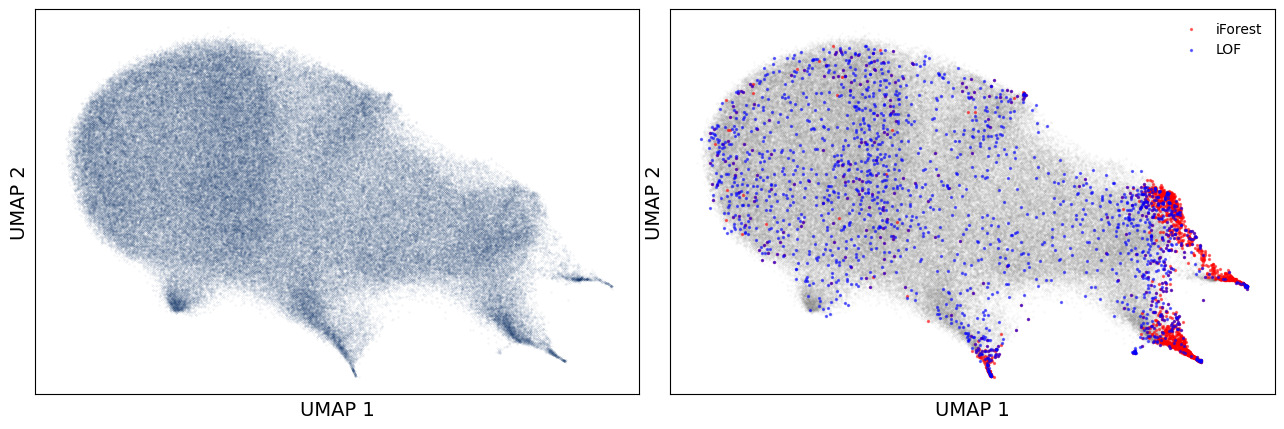

In [ ]:
bin_id = "bin_03"

x = embedding[:, 0]
y = embedding[:, 1]

col = "iforest_score"
df_ = iforest_df_dict[bin_id].copy()
is_iforest_anomaly, is_iforest_inlier = get_anomaly_masks(df_, col)

iforest_anomalies = embedding[is_iforest_anomaly, :]
iforest_inliers = embedding[is_iforest_inlier, :]

col = "lof"
df_ = lof_df_dict[bin_id].copy()
is_lof_anomaly, is_lof_inlier = get_anomaly_masks(df_, col)

lof_anomalies = embedding[is_lof_anomaly, :]
lof_inliers = embedding[is_lof_inlier, :]


fig, axes = plt.subplots(
    1, 2, figsize=(16, 5), sharey=True, gridspec_kw={"wspace": 0.05}
)

# -------------------------------------------------------------
# Left Panel: Standard Scatter Plot
# -------------------------------------------------------------
# Use s=0.1 and alpha=0.1 to handle the extreme density of 180k points
axes[0].scatter(x, y, s=0.05, alpha=0.15, color="#08306B", edgecolors=None)
# -------------------------------------------------------------
# Right Panel: anomalies
# -------------------------------------------------------------
axes[1].scatter(x, y, s=0.05, alpha=0.15, color="gray", edgecolors=None)

axes[1].scatter(
    iforest_anomalies[:, 0],
    iforest_anomalies[:, 1],
    s=2,
    alpha=0.5,
    color="red",
    label="iForest",
    # edgecolors=None
)
axes[1].scatter(
    lof_anomalies[:, 0],
    lof_anomalies[:, 1],
    s=2,
    alpha=0.5,
    color="blue",
    label="LOF",
    # edgecolors=None
)


# Clean up the axes (UMAP coordinates are relative, so ticks don't mean much)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("UMAP 1", fontsize=14)
    ax.set_ylabel("UMAP 2", fontsize=14)
    ax.legend(frameon=False)